In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
ruta_carpeta = Path(
    "./Resultados/Tablas_de_metricas"
)

ruta_salida = Path(
    "./Resultados/Graficos"
)
ruta_salida.mkdir(parents=True, exist_ok=True)

Acá abajo seleccionar la métrica que se quiere graficar

In [30]:
# Métrica a evaluar
# puede ser: NS,Pbias,CV,Pearson,CRPSSad,Brier_Q10,Brier_Q10_Q25,Brier_Q25_Q75,Brier_Q75_Q90,Brier_Q90
metrica_evaluar = "Brier_Q90"

In [31]:
# Acumulador intercuenca
inter_cuenca = []

for ruta_csv in ruta_carpeta.glob("*.csv"):
    df = pd.read_csv(ruta_csv)

    cuenca = ruta_csv.stem  # nombre del archivo = cuenca

    # chequeo defensivo
    if metrica_evaluar not in df.columns:
        raise ValueError(f"{metrica_evaluar} no está en {ruta_csv.name}")

    # extraer lead + métrica
    tmp = df[["lead", metrica_evaluar]].copy()
    tmp["cuenca"] = cuenca

    inter_cuenca.append(tmp)


           p25       p50
lead                    
1     0.084033  0.088651
2     0.094000  0.095312
3     0.095236  0.096437
4     0.095885  0.096397
5     0.096317  0.096809
6     0.096292  0.096750


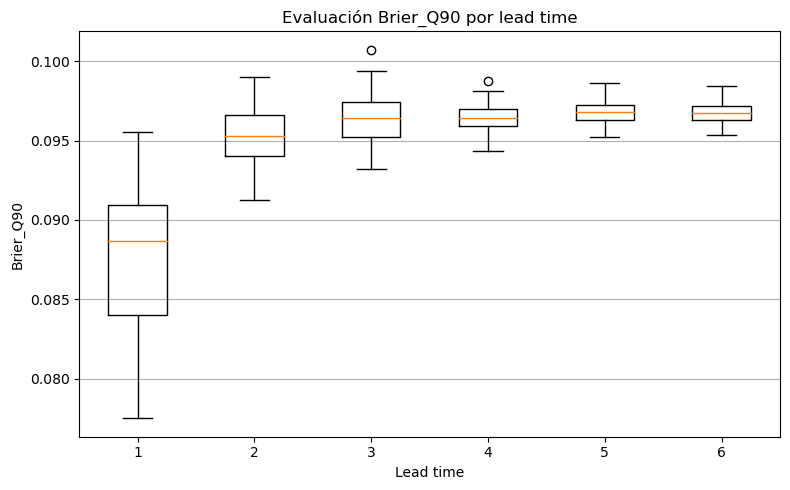

In [32]:
# DataFrame final y graficar

inter_cuenca = pd.concat(inter_cuenca, ignore_index=True)


percentiles = (
    inter_cuenca
    .groupby("lead")[metrica_evaluar]
    .quantile([0.25, 0.50])
    .unstack()
    .rename(columns={0.25: "p25", 0.50: "p50"})
)

print(percentiles)

leads = sorted(inter_cuenca["lead"].unique())

box_data = [
    inter_cuenca.loc[inter_cuenca["lead"] == l, metrica_evaluar].dropna()
    for l in leads
]

plt.figure(figsize=(8, 5))
plt.boxplot(box_data, labels=leads, showfliers=True)
plt.xlabel("Lead time")
plt.ylabel(metrica_evaluar)
plt.title(f"Evaluación {metrica_evaluar} por lead time")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(ruta_salida / f"Brier_boxplot_{metrica_evaluar}.png", dpi=300)
plt.show()

